In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/cleaned_sales_data.csv')

## 4.Exploratory analysis

In [ ]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
df.shape

(51290, 21)

In [ ]:
df.columns.tolist()

['order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_name',
 'segment',
 'state',
 'country',
 'market',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit',
 'shipping_cost',
 'order_priority',
 'year']

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.to_period('M')


In [ ]:
df[['order_date', 'order_month']].head()

,order_date,order_month
0,2011-01-01,2011-01
1,2011-01-01,2011-01
2,2011-01-01,2011-01
3,2011-01-01,2011-01
4,2011-01-01,2011-01


In [ ]:
monthly_sales = df.groupby('order_month')['sales'].sum().reset_index()

In [ ]:
monthly_sales.head()

,order_month,sales
0,2011-01,4081206645114553142769126673382118541931591951...
1,2011-02,"2862912061633524013101404182782320212112101,05..."
2,2011-03,"5511,3141,4713646342467051,2442154585883771953..."
3,2011-04,4972965681581398486123804868122452044302518671...
4,2011-05,"2,7541,0574801,3892463095213372661562362888147..."


In [ ]:
df['sales'].dtype

dtype('O')

In [ ]:
df['sales'].head(10)

,sales
0,408
1,120
2,66
3,45
4,114
5,55
6,314
7,276
8,912
9,667


In [ ]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [ ]:
df['sales'].dtype

dtype('float64')

In [ ]:
df['sales'].isnull().sum()

np.int64(2630)

In [ ]:
df[df['sales'].isna()].head(10)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,order_month
27,MX-2011-111255,2011-01-04,09-01-2011,Second Class,Russell Applegate,Consumer,Parana,Brazil,LATAM,South,...,Bookcases,"Dania Classic Bookcase, Pine",NaN,6,0.0,609.8400,109.13,Medium,2011,2011-01
43,MX-2011-109267,2011-01-05,09-01-2011,Standard Class,Jennifer Halladay,Consumer,Veracruz,Mexico,LATAM,North,...,Appliances,"Hoover Stove, Black",NaN,8,0.0,999.3600,191.20,Medium,2011,2011-01
58,CA-2011-167199,2011-01-07,11-01-2011,Standard Class,Maria Etezadi,Home Office,Kentucky,United States,US,South,...,Chairs,Global Deluxe High-Back Manager's Chair,NaN,9,0.0,746.4078,258.99,High,2011,2011-01
83,AO-2011-1670,2011-01-08,13-01-2011,Standard Class,Henia Zydlo,Consumer,Benguela,Angola,Africa,Africa,...,Bookcases,"Ikea Classic Bookcase, Pine",NaN,6,0.0,49.5000,349.87,High,2011,2011-01
84,IN-2011-19330,2011-01-08,12-01-2011,Second Class,Nicole Fjeld,Home Office,Yunnan,China,APAC,North Asia,...,Machines,"Panasonic Inkjet, White",NaN,7,0.0,260.8200,275.52,Medium,2011,2011-01
100,IN-2011-61302,2011-01-10,11-01-2011,First Class,Dan Lawera,Consumer,Queensland,Australia,APAC,Oceania,...,Phones,"Nokia Smart Phone, with Caller ID",NaN,5,0.1,511.0950,665.27,Medium,2011,2011-01
125,ES-2011-5158390,2011-01-11,11-01-2011,Same Day,Roy Collins,Consumer,England,United Kingdom,EU,North,...,Chairs,"SAFCO Executive Leather Armchair, Red",NaN,3,0.0,13.7700,178.98,Medium,2011,2011-01
126,US-2011-163874,2011-01-11,12-01-2011,First Class,Philip Fox,Consumer,México,Mexico,LATAM,North,...,Storage,"Smead Lockers, Blue",NaN,10,0.0,238.0000,103.84,Medium,2011,2011-01
163,EG-2011-4270,NaT,18-01-2011,Standard Class,Roger Demir,Consumer,Aswan,Egypt,Africa,Africa,...,Copiers,"HP Fax Machine, Laser",NaN,4,0.0,479.8800,55.62,Medium,2011,NaT
173,CA-2011-157147,NaT,19-01-2011,Standard Class,Brian Dahlen,Consumer,California,United States,US,West,...,Storage,Tennsco 6- and 18-Compartment Lockers,NaN,5,0.0,238.6530,187.65,High,2011,NaT


In [ ]:
df[df['sales'].isna()].shape

(2630, 22)

In [ ]:
df['sales'] = (
    df['sales']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

In [ ]:
df['sales'].head(10)

,sales
0,408.0
1,120.0
2,66.0
3,45.0
4,114.0
5,55.0
6,314.0
7,276.0
8,912.0
9,667.0


In [ ]:
df['sales'].dtype

dtype('float64')

In [ ]:
df['sales'].isnull().sum()

np.int64(2630)

In [ ]:
monthly_sales = df.groupby('order_month')['sales'].sum().reset_index()

In [ ]:
monthly_sales.head()

,order_month,sales
0,2011-01,25344.0
1,2011-02,26445.0
2,2011-03,35909.0
3,2011-04,30751.0
4,2011-05,35408.0


## 5.Visualization

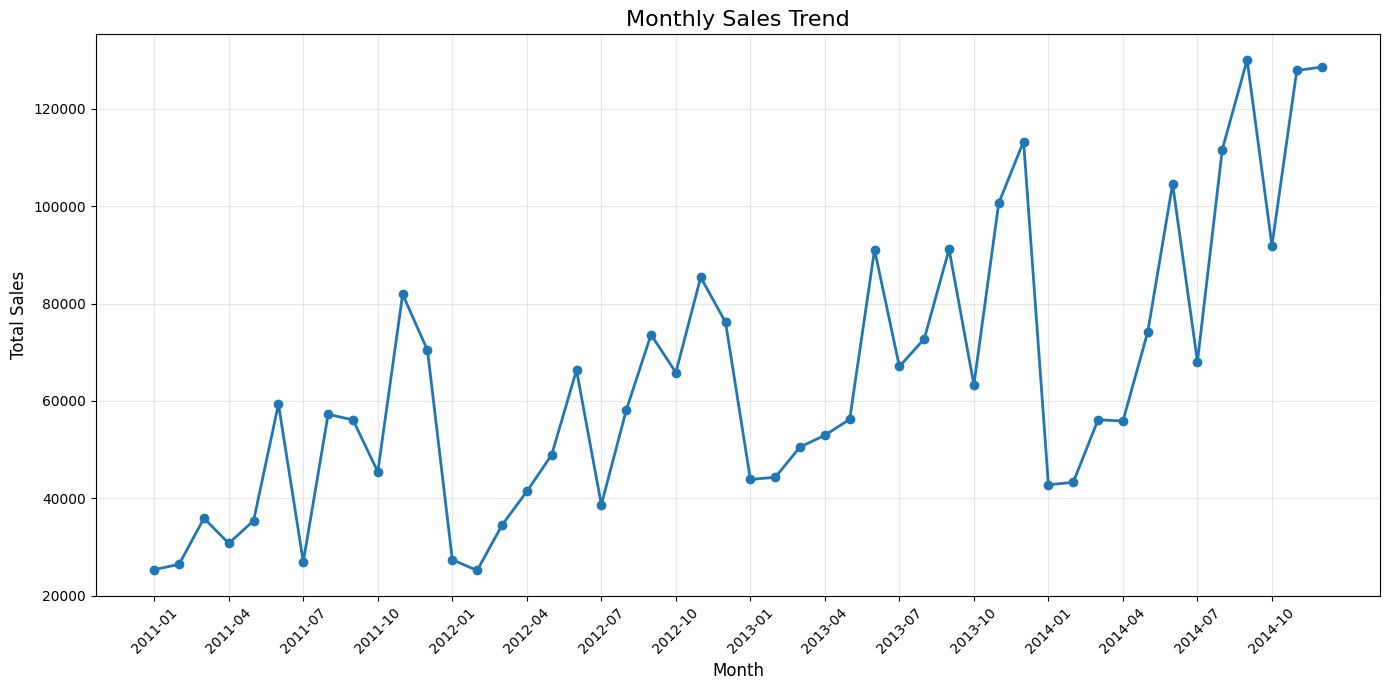

In [ ]:
plt.figure(figsize=(14, 7))

plt.plot(
    monthly_sales['order_month'].astype(str),
    monthly_sales['sales'],
    marker='o',
    linewidth=2
)

plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)

# Show every 3rd month to reduce crowding
plt.xticks(
    range(0, len(monthly_sales), 3),
    monthly_sales['order_month'].astype(str).iloc[::3],
    rotation=45
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    'monthly_sales_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
category_sales = (
    df.groupby('category')['sales']
    .sum()
    .sort_values(ascending=False)
)

category_sales

,sales
category,
Office Supplies,2790258.0
Technology,2638265.0
Furniture,2406605.0


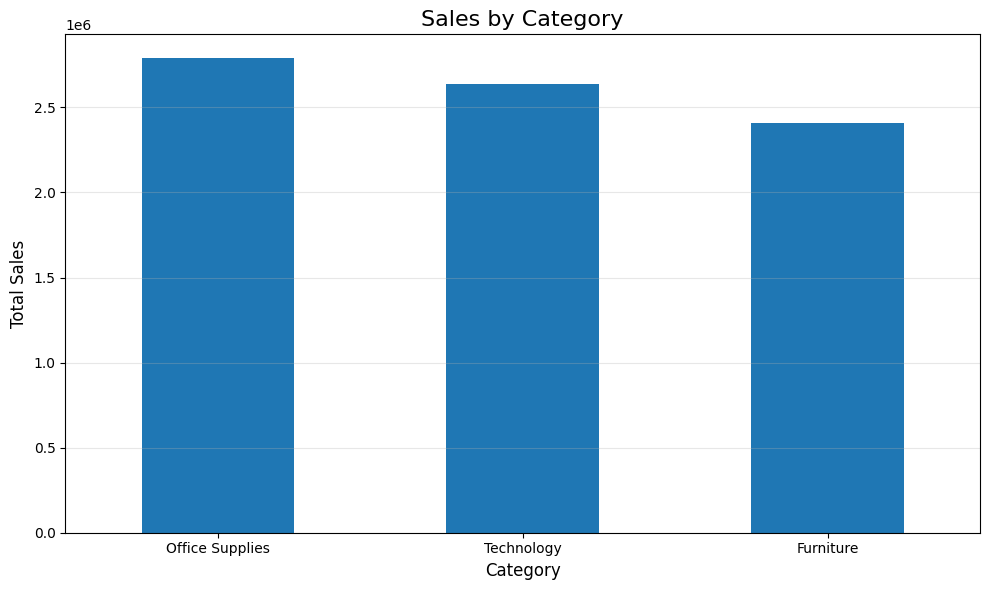

In [ ]:
plt.figure(figsize=(10, 6))

category_sales.plot(kind='bar')

plt.title('Sales by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

plt.savefig(
    'sales_by_category.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 6. Analysis

In [ ]:
highest_month = monthly_sales.loc[
    monthly_sales['sales'].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales['sales'].idxmin()
]

print("Highest Sales Month:")
print(highest_month)

print("\nLowest Sales Month:")
print(lowest_month)

Highest Sales Month:
order_month     2014-09
sales          130067.0
Name: 44, dtype: object

Lowest Sales Month:
order_month    2012-02
sales          25181.0
Name: 13, dtype: object


In [ ]:
highest_category = category_sales.idxmax()
lowest_category = category_sales.idxmin()

print("Highest-selling category:", highest_category)
print("Lowest-selling category:", lowest_category)

Highest-selling category: Office Supplies
Lowest-selling category: Furniture


In [ ]:
total_sales = df['sales'].sum()

print("Total Sales:", total_sales)

Total Sales: 7835128.0


## 7. Prediction Model
### 7.1 Linear Regression

In [ ]:
prediction_data = monthly_sales.copy()

prediction_data['month_number'] = range(
    1,
    len(prediction_data) + 1
)

prediction_data.head()

,order_month,sales,month_number
0,2011-01,25344.0,1
1,2011-02,26445.0,2
2,2011-03,35909.0,3
3,2011-04,30751.0,4
4,2011-05,35408.0,5


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
split_point = int(len(prediction_data) * 0.8)

train = prediction_data.iloc[:split_point]
test = prediction_data.iloc[split_point:]

X_train = train[['month_number']]
y_train = train['sales']

X_test = test[['month_number']]
y_test = test['sales']

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

results

,Actual Sales,Predicted Sales
0,56147.0,78095.736842
1,55872.0,79231.441296
2,74178.0,80367.145749
3,104566.0,81502.850202
4,68087.0,82638.554656
5,111635.0,83774.259109
6,130067.0,84909.963563
7,91901.0,86045.668016
8,127886.0,87181.372470
9,128591.0,88317.076923


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 24896.368825910926
Root Mean Squared Error (RMSE): 28174.26487239618
R² Score: 0.00970458953297515


In [ ]:
future_months = np.arange(
    len(prediction_data) + 1,
    len(prediction_data) + 7
).reshape(-1, 1)

future_predictions = model.predict(future_months)

future_sales = pd.DataFrame({
    'Future Month Number': future_months.flatten(),
    'Predicted Sales': future_predictions
})

future_sales

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Future Month Number,Predicted Sales
0,49,89452.781377
1,50,90588.485830
2,51,91724.190283
3,52,92859.894737
4,53,93995.599190
5,54,95131.303644


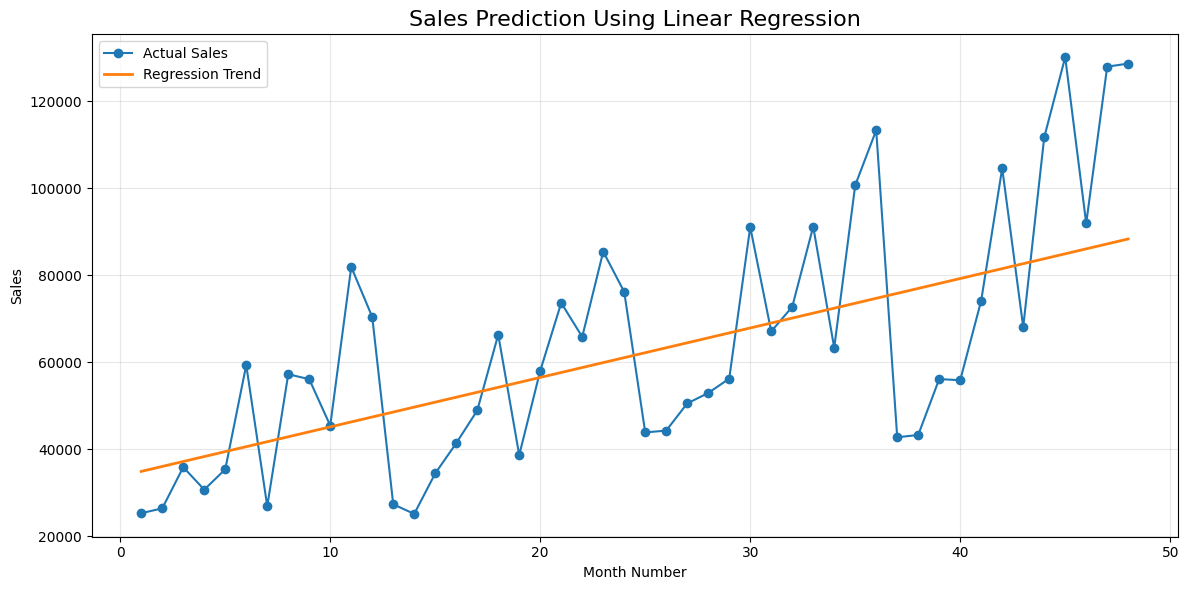

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    prediction_data['month_number'],
    prediction_data['sales'],
    marker='o',
    label='Actual Sales'
)

plt.plot(
    prediction_data['month_number'],
    model.predict(prediction_data[['month_number']]),
    linewidth=2,
    label='Regression Trend'
)

plt.title('Sales Prediction Using Linear Regression', fontsize=16)
plt.xlabel('Month Number')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    'sales_prediction_linear_regression.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 8. Interactive Sales Dashboard

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

In [ ]:
region_sales = (
    df.groupby('region')['sales']
    .sum()
    .sort_values(ascending=False)
)

top_products = (
    df.groupby('product_name')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_quantity = df['quantity'].sum()
average_discount = df['discount'].mean()

In [ ]:
fig = make_subplots(
    rows=4,
    cols=2,
    specs=[
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "indicator"}, {"type": "indicator"}],
        [{"type": "xy"}, {"type": "xy"}],
        [{"type": "xy"}, {"type": "xy"}]
    ],
    subplot_titles=(
        "Total Sales",
        "Total Profit",
        "Total Quantity",
        "Average Discount",
        "Monthly Sales Trend",
        "Sales by Category",
        "Sales by Region",
        "Top 10 Products"
    ),
    vertical_spacing=0.10,
    horizontal_spacing=0.10
)

# KPI 1 - Total Sales
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_sales,
        number={"valueformat": ",.0f"}
    ),
    row=1, col=1
)

# KPI 2 - Total Profit
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_profit,
        number={"valueformat": ",.0f"}
    ),
    row=1, col=2
)

# KPI 3 - Total Quantity
fig.add_trace(
    go.Indicator(
        mode="number",
        value=total_quantity,
        number={"valueformat": ",.0f"}
    ),
    row=2, col=1
)

# KPI 4 - Average Discount
fig.add_trace(
    go.Indicator(
        mode="number",
        value=average_discount,
        number={"valueformat": ".2f"}
    ),
    row=2, col=2
)

# Monthly Sales
fig.add_trace(
    go.Scatter(
        x=monthly_sales['order_month'].astype(str),
        y=monthly_sales['sales'],
        mode='lines+markers',
        name='Monthly Sales'
    ),
    row=3, col=1
)

# Category Sales
fig.add_trace(
    go.Bar(
        x=category_sales.index,
        y=category_sales.values,
        name='Category Sales'
    ),
    row=3, col=2
)

# Region Sales
fig.add_trace(
    go.Bar(
        x=region_sales.index,
        y=region_sales.values,
        name='Region Sales'
    ),
    row=4, col=1
)

# Top Products
fig.add_trace(
    go.Bar(
        x=top_products.values,
        y=top_products.index,
        orientation='h',
        name='Top Products'
    ),
    row=4, col=2
)

fig.update_layout(
    title={
        'text': 'SALES TREND ANALYTICS DASHBOARD',
        'x': 0.5,
        'xanchor': 'center'
    },
    height=1600,
    showlegend=False
)

fig.update_xaxes(tickangle=45, row=3, col=1)

fig.show()

In [ ]:
fig.write_html("sales_dashboard.html")